# DBSCAN from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** is a clustering algorithm that groups points based on density rather than distance to a centroid. Unlike K-Means, DBSCAN can discover clusters of **arbitrary shape** and automatically identifies **noise points**.

DBSCAN uses two parameters:
- **eps** — the maximum distance between two points to be considered neighbors
- **min_samples** — the minimum number of points required to form a dense region

Points are classified as:
- **Core points** — have at least min_samples neighbors within eps distance
- **Border points** — within eps of a core point but not a core point themselves
- **Noise points** — not within eps of any core point, labeled as **-1**

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.unsupervised_learning.dbscan import DBSCAN
from rice_ml.unsupervised_learning.k_means import KMeans
from rice_ml.processing.preprocessing import StandardScaler

## Dataset 1: Moons (Non-Linear Clusters)

The **moons dataset** is a classic benchmark for density-based clustering. It contains two interleaving half-circles that K-Means cannot separate because they are not convex or spherical.

In [10]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

scaler = StandardScaler().fit(X_moons)
X_moons_scaled = scaler.transform(X_moons)

print(f"Dataset shape: {X_moons_scaled.shape}")
print(f"True number of clusters: {len(np.unique(y_moons))}")

Dataset shape: (300, 2)
True number of clusters: 2


## DBSCAN vs K-Means on Moons Dataset

In [11]:
dbscan = DBSCAN(eps=0.3, min_samples=5).fit(X_moons_scaled)
kmeans = KMeans(k=2, random_state=42).fit(X_moons_scaled)

n_clusters = len(np.unique(dbscan.labels_[dbscan.labels_ != -1]))
n_noise = np.sum(dbscan.labels_ == -1)

print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points")
print(f"K-Means found 2 clusters (forced)")

DBSCAN found 2 clusters and 0 noise points
K-Means found 2 clusters (forced)


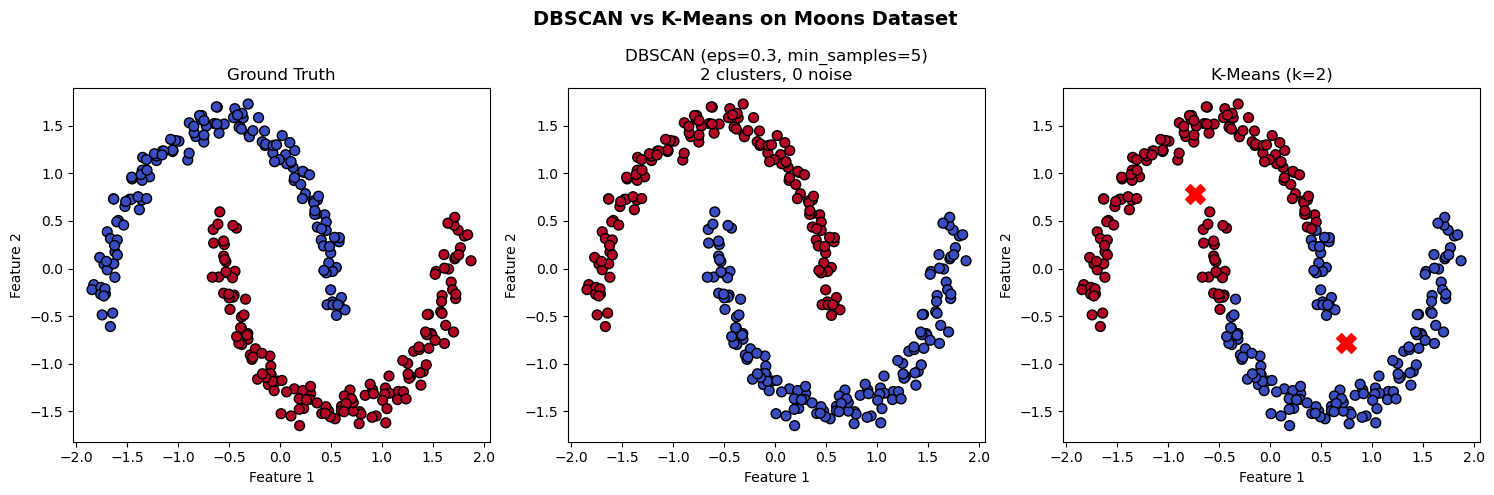

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=y_moons, cmap='coolwarm', edgecolors='k', s=50)
axes[0].set_title('Ground Truth')

colors_db = ['red' if l == -1 else l for l in dbscan.labels_]
axes[1].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=dbscan.labels_, cmap='coolwarm', edgecolors='k', s=50)
axes[1].set_title(f'DBSCAN (eps=0.3, min_samples=5)\n{n_clusters} clusters, {n_noise} noise')

axes[2].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=kmeans.labels_, cmap='coolwarm', edgecolors='k', s=50)
axes[2].scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
                c='red', marker='X', s=200, zorder=5)
axes[2].set_title('K-Means (k=2)')

for ax in axes:
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('DBSCAN vs K-Means on Moons Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Dataset 2: Blobs with Noise

DBSCAN handles noise naturally by labeling outlier points as -1. Let us test this on a dataset with intentional noise points.

In [13]:
X_blobs, y_blobs = make_blobs(n_samples=250, centers=3,
                               cluster_std=0.5, random_state=42)
noise = np.random.default_rng(42).uniform(
    low=-6, high=6, size=(30, 2))
X_noisy = np.vstack([X_blobs, noise])
y_noisy = np.concatenate([y_blobs, np.full(30, -1)])

scaler2 = StandardScaler().fit(X_noisy)
X_noisy_scaled = scaler2.transform(X_noisy)

print(f"Dataset shape: {X_noisy_scaled.shape}")
print(f"True noise points: 30")

Dataset shape: (280, 2)
True noise points: 30


In [14]:
dbscan2 = DBSCAN(eps=0.5, min_samples=5).fit(X_noisy_scaled)
kmeans2 = KMeans(k=3, random_state=42).fit(X_noisy_scaled)

n_clusters2 = len(np.unique(dbscan2.labels_[dbscan2.labels_ != -1]))
n_noise2 = np.sum(dbscan2.labels_ == -1)

print(f"DBSCAN found {n_clusters2} clusters and {n_noise2} noise points")

DBSCAN found 3 clusters and 7 noise points


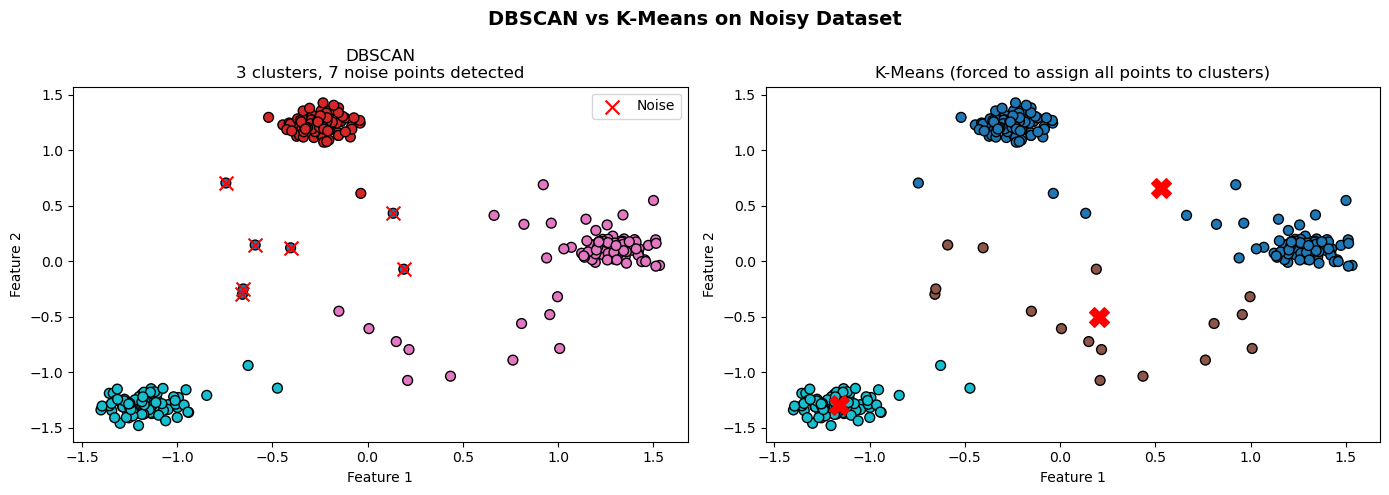

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_noisy_scaled[:, 0], X_noisy_scaled[:, 1],
                c=dbscan2.labels_, cmap='tab10', edgecolors='k', s=50)
noise_mask = dbscan2.labels_ == -1
axes[0].scatter(X_noisy_scaled[noise_mask, 0], X_noisy_scaled[noise_mask, 1],
                c='red', marker='x', s=100, zorder=5, label='Noise')
axes[0].set_title(f'DBSCAN\n{n_clusters2} clusters, {n_noise2} noise points detected')
axes[0].legend()

axes[1].scatter(X_noisy_scaled[:, 0], X_noisy_scaled[:, 1],
                c=kmeans2.labels_, cmap='tab10', edgecolors='k', s=50)
axes[1].scatter(kmeans2.centroids[:, 0], kmeans2.centroids[:, 1],
                c='red', marker='X', s=200, zorder=5)
axes[1].set_title('K-Means (forced to assign all points to clusters)')

for ax in axes:
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('DBSCAN vs K-Means on Noisy Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Effect of eps and min_samples Parameters

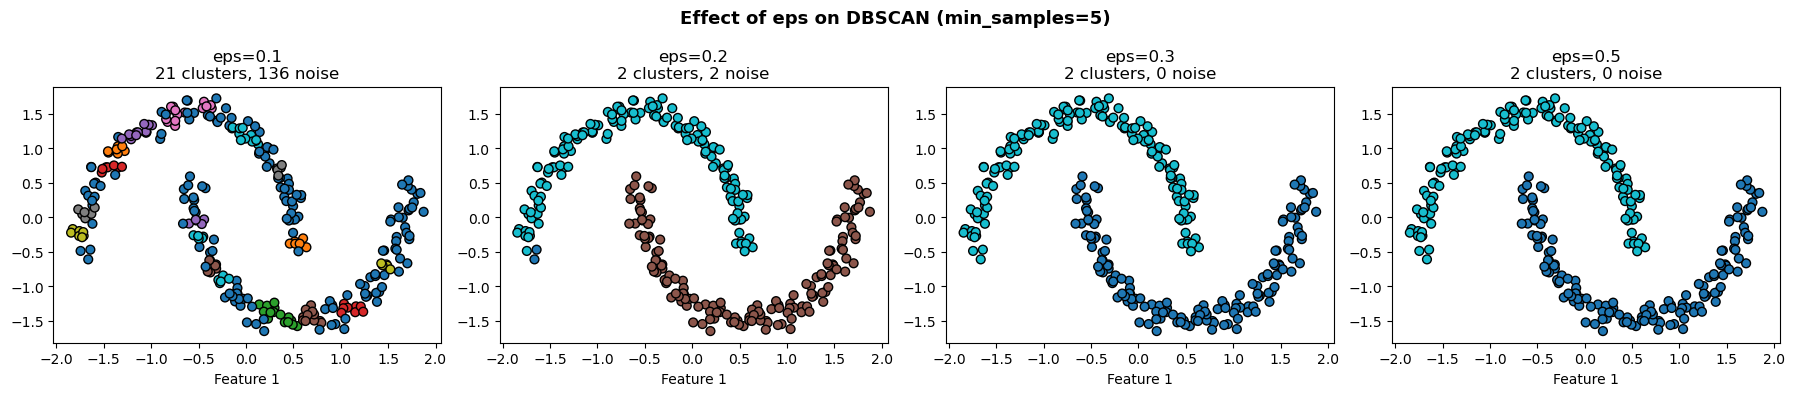

In [16]:
eps_values = [0.1, 0.2, 0.3, 0.5]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, eps in zip(axes, eps_values):
    m = DBSCAN(eps=eps, min_samples=5).fit(X_moons_scaled)
    n_c = len(np.unique(m.labels_[m.labels_ != -1]))
    n_n = np.sum(m.labels_ == -1)
    ax.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
               c=m.labels_, cmap='tab10', edgecolors='k', s=40)
    ax.set_title(f'eps={eps}\n{n_c} clusters, {n_n} noise')
    ax.set_xlabel('Feature 1')

plt.suptitle('Effect of eps on DBSCAN (min_samples=5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Discussion

- DBSCAN successfully identifies the **2 true clusters** in the moons dataset with **0 noise points**, perfectly capturing the curved structure that K-Means cannot handle
- The **moons comparison plot** beautifully demonstrates DBSCAN's key advantage, showing it follows the shape of each half-moon while K-Means cuts a straight line through both moons, incorrectly grouping points based on proximity to centroids rather than density connectivity
- On the **noisy blobs dataset**, DBSCAN correctly finds **3 clusters and 7 noise points**, automatically isolating outliers without contaminating the main clusters
- K-Means on the same noisy data is forced to assign every noise point to a cluster, which distorts the centroids and creates messy boundaries as seen in the right plot
- The **eps sensitivity plot** clearly shows how this single parameter controls the algorithm's behavior
- At eps=0.1, the radius is too small, producing 21 fragmented clusters with 136 noise points
- At eps=0.2 to 0.5, DBSCAN consistently recovers the true 2 cluster structure with minimal or zero noise
- This stability across a range of eps values, from 0.2 to 0.5, suggests our parameters are well-chosen for this dataset
- **Strengths** include the ability to find arbitrarily shaped clusters, automatic noise detection, no need to specify k in advance, and robustness to outliers
- **Weaknesses** include sensitivity to eps and min_samples, difficulty handling clusters of varying density, and reduced effectiveness in high-dimensional spaces where distance metrics become less meaningful
- DBSCAN complements K-Means well, with K-Means being faster and more scalable for spherical clusters while DBSCAN excels at irregular shapes and noisy data